IMPORTING LIBRARIES

In [1]:
import os
from PIL import Image
import pandas as pd
import numpy as np
import cv2
import random
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

THE PICTURE AS BEFORE

In [2]:
 # Display folder contents

def collect_image_info(base_folder):
    data = []
    for root, _, files in os.walk(base_folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(root, file)
                rel_folder = os.path.relpath(root, base_folder)
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        format = img.format
                except:
                    width = height = format = None        
                data.append({
                    "Folder": rel_folder,
                    "File Name": file,''
                    "Format": format,
                    "Size (W*h)": f"{width}x{height}",
                    })
    df = pd.DataFrame(data)
    return df

# Define a constant for dataset base folder
dataset_dir = "../train"
df_images = collect_image_info(dataset_dir)
print(df_images.head())
                
    

  Folder    File Name Format Size (W*h)
0      .  img_001.jpg   JPEG    512x512
1      .  img_002.jpg   JPEG    512x512
2      .  img_003.jpg   JPEG    512x512
3      .  img_004.jpg   JPEG    512x512
4      .  img_005.jpg   JPEG    512x512


DATA CLEANING 

In [3]:
# Function to check if an image file is valid
def is_valid_image(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()  # Verify that it's an image
        return True
    except (IOError, SyntaxError):
        return False

In [4]:
# Checking for corrupted images
dataset_directory = "../train"
corrupted_images = []

for root, dirs, files in os.walk(dataset_directory):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            file_path = os.path.join(root, file)
            if not is_valid_image(file_path):
                corrupted_images.append(file_path)

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [5]:
# Resizing and Normalizing the dataset

TARGET_SIZE = (224, 224)

def preprocess_image(file_path, save_dir):
    try:
        with Image.open(file_path) as img:
            img = img.convert('RGB')  # Ensure 3 color channels
            img = img.resize(TARGET_SIZE)  # Resize to target size

            # Normalize: convert to array and divide by 255 to scale to [0, 1]                  
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]

            #Optional: Save the preprocessed image (remove this if just using in memory)
            save_path = os.path.join(save_dir, os.path.basename(file_path))
            img.save(save_path)  # Save the resized image

            return img_array  # Return array if needed for model input                                  
    except Exception as e:
        print(f"Failed to process {file_path}: {e}")
        return None

In [6]:
# Applying to all images 

input_directory = "../train"
output_directory = "../processed_train" 
os.makedirs(output_directory, exist_ok=True)    

for root, dirs, files in os.walk(input_directory):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            file_path = os.path.join(root, file)
            preprocess_image(file_path, output_directory)

In [7]:
# Counting images per class
import os

dataset_path = '../train'

images = [f for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print("Total number of images:", len(images))


Total number of images: 6764


In [9]:
import os

folder_path = '../train'
 
files = os.listdir(folder_path)

for i, file in enumerate(files):
     if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
         new_name = f"img_{i+1:03d}.jpg"  # Change extension to .jpg
         old_path = os.path.join(folder_path, file)
         new_path = os.path.join(folder_path, new_name)
         os.rename(old_path, new_path)

         print("Renaming complete!")


Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming com

FileExistsError: [WinError 183] Cannot create a file when that file already exists: '../train\\img_1000.jpg' -> '../train\\img_101.jpg'

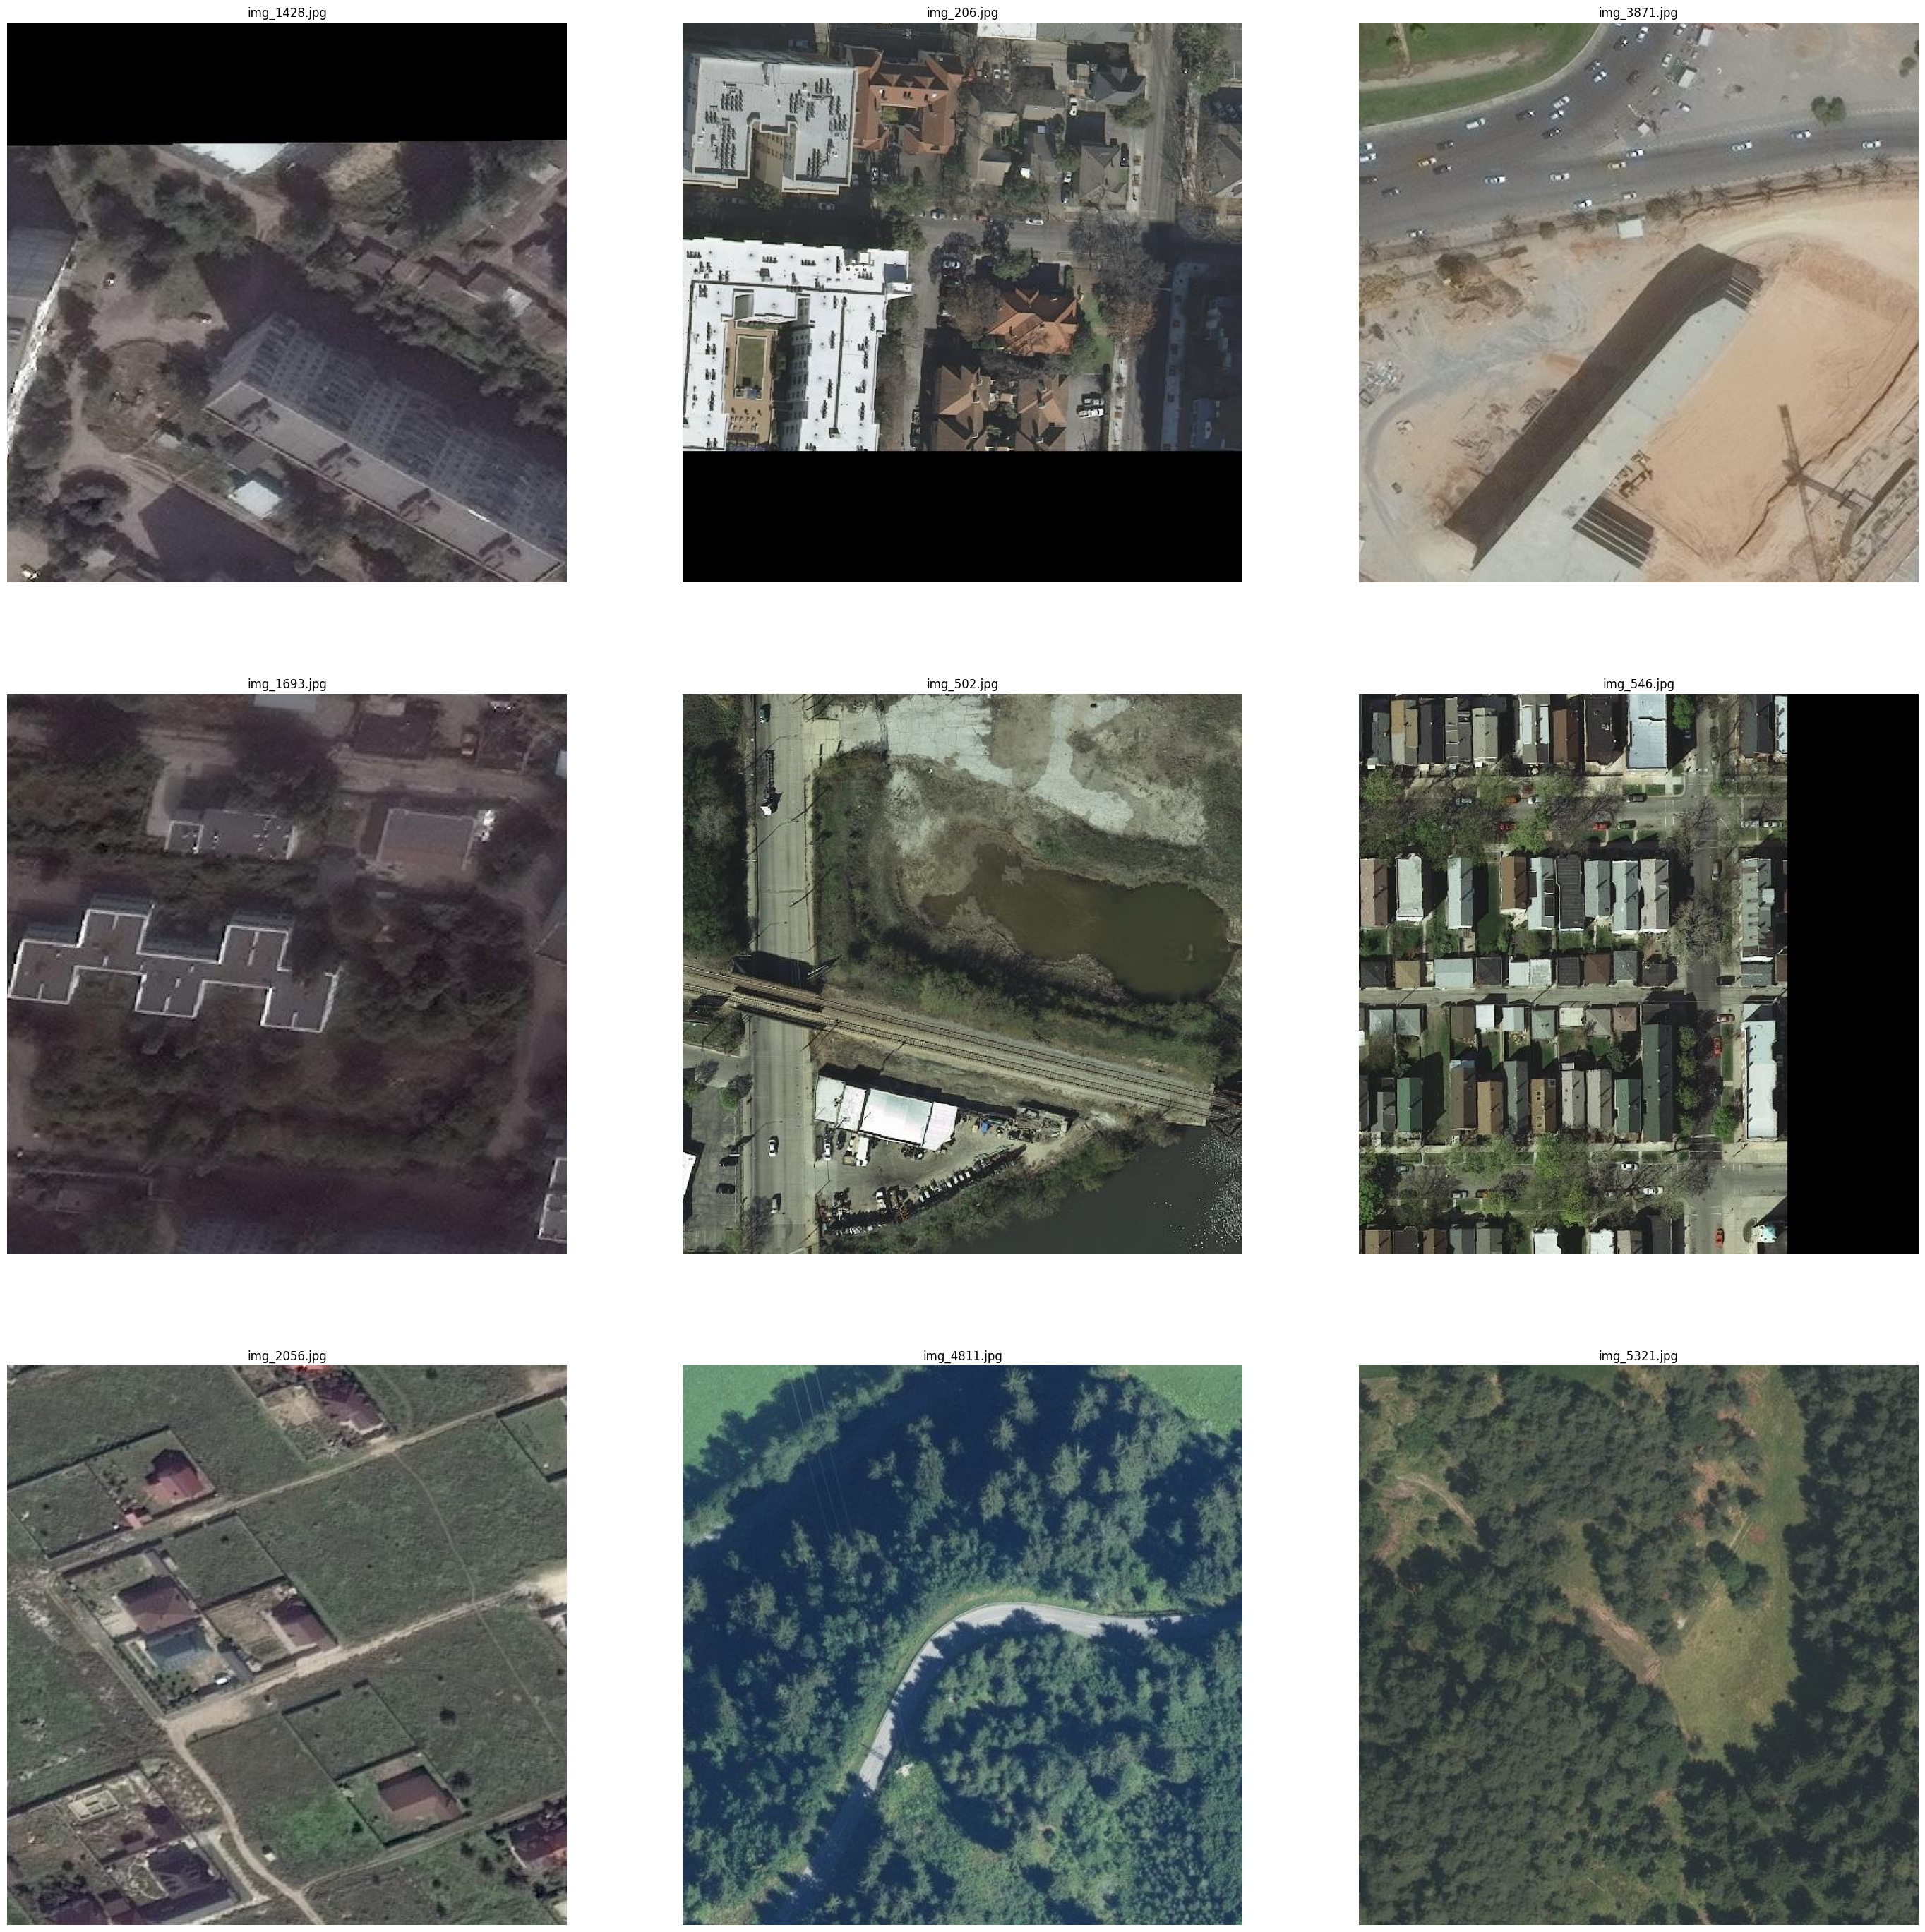

In [ ]:
# Display random images from the dataset

dataset_path = '../train'

images = os.listdir(dataset_path)

# Select 9 random images

sample_images = random.sample(images, 9)

plt.figure(figsize=(35, 35))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(dataset_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for correct color display

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = '../train'
classes = os.listdir(dataset_path)
print("Classes:", classes)


Classes: ['img_001.jpg', 'img_002.jpg', 'img_003.jpg', 'img_004.jpg', 'img_005.jpg', 'img_006.jpg', 'img_007.jpg', 'img_008.jpg', 'img_009.jpg', 'img_010.jpg', 'img_011.jpg', 'img_012.jpg', 'img_013.jpg', 'img_014.jpg', 'img_015.jpg', 'img_016.jpg', 'img_017.jpg', 'img_018.jpg', 'img_019.jpg', 'img_020.jpg', 'img_021.jpg', 'img_022.jpg', 'img_023.jpg', 'img_024.jpg', 'img_025.jpg', 'img_026.jpg', 'img_027.jpg', 'img_028.jpg', 'img_029.jpg', 'img_030.jpg', 'img_031.jpg', 'img_032.jpg', 'img_033.jpg', 'img_034.jpg', 'img_035.jpg', 'img_036.jpg', 'img_037.jpg', 'img_038.jpg', 'img_039.jpg', 'img_040.jpg', 'img_041.jpg', 'img_042.jpg', 'img_043.jpg', 'img_044.jpg', 'img_045.jpg', 'img_046.jpg', 'img_047.jpg', 'img_048.jpg', 'img_049.jpg', 'img_050.jpg', 'img_051.jpg', 'img_052.jpg', 'img_053.jpg', 'img_054.jpg', 'img_055.jpg', 'img_056.jpg', 'img_057.jpg', 'img_058.jpg', 'img_059.jpg', 'img_060.jpg', 'img_061.jpg', 'img_062.jpg', 'img_063.jpg', 'img_064.jpg', 'img_065.jpg', 'img_066.jpg', 

FEATURE EXTRACTION

In [ ]:
# Feature extraction function

def extract_image_features(img_array, num_bins=10):
    """
    Extract average brightness and color histogram  from an image array.

    Parameters:
        img_array: numpy array of shape (224, 224, 3) 
        num_bins: number of bins for histogram

    Returns
        avg_brightness: float
        hist_features: list of floats (flattened histogram)
    """
    # Average brightness: mean of all channels
    avg_brightness = np.mean(img_array)

    # Histogram: calculate for each channel separately
    hist_r, _ = np.histogram(img_array[:, :, 0], bins=num_bins, range=(0, 1), density=True)
    hist_g, _ = np.histogram(img_array[:, :, 1], bins=num_bins, range=(0, 1), density=True)
    hist_b, _ = np.histogram(img_array[:, :, 2], bins=num_bins, range=(0, 1), density=True)

    # Combine all histograms into one flat list
    hist_features = np.concatenate([hist_r, hist_g, hist_b]).tolist()

    return avg_brightness, hist_features

In [ ]:
# Load and preprocess images from the dataset directory
data_dir = '../train'
img_size = 224

X = []
y = []      

for label in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, label)

    if not os.path.isdir(folder_path):
        continue # Skip if not a folder     

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Read and preprocess the image
        img = cv2.imread(img_path)
        if img is None:
            continue  # Skip if the image cannot be read

        # Preprocess the image (e.g., resize, normalize)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0 # Normalize 

        # Append image and label
        X.append(img)
        y.append(label) # the folder name is the class label

In [ ]:
X_additional_features = []

for img in X:
    avg_brightness, hist_features = extract_image_features(img)
    # Combine into one flat feature vector (brightness + histogram)
    combined_features = [avg_brightness] + hist_features
    X_additional_features.append(combined_features)

In [ ]:
print(X)
print(y)
# Just to make sure the data is in the right format
print("Number of images:", len(X))
print("Number of classes:", len(set(y)))    

[]
[]
Number of images: 0
Number of classes: 0


In [ ]:
X_additional_features = np.array(X_additional_features)
y = np.array(y)

In [ ]:
data_dir = '../train'
img_size = 224

X_images = []
X_features = []
y_labels= []

def extract_features(img_array, num_bins=10):
    avg_brightness = np.mean(img_array)

    hist_r, _ = np.histogram(img_array[:, :, 0], bins=num_bins, range=(0, 1), density=True)
    hist_g, _ = np.histogram(img_array[:, :, 1], bins=num_bins, range=(0, 1), density=True)
    hist_b, _ = np.histogram(img_array[:, :, 2], bins=num_bins, range=(0, 1), density=True)

    hist_features = np.concatenate([hist_r, hist_g, hist_b]).tolist()   
    return avg_brightness, hist_features

# Load images and extract features
for label in os.listdir(data_dir):  
    folder_path = os.path.join(data_dir, label)

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0

        X_images.append(img)
        y_labels.append(label)

        avg_brightness, hist_features = extract_features(img)
        combined_features = [avg_brightness] + hist_features
        X_features.append(combined_features)

# Convert to arrays
X_features = np.array(X_features)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

VISUALIXATIONS

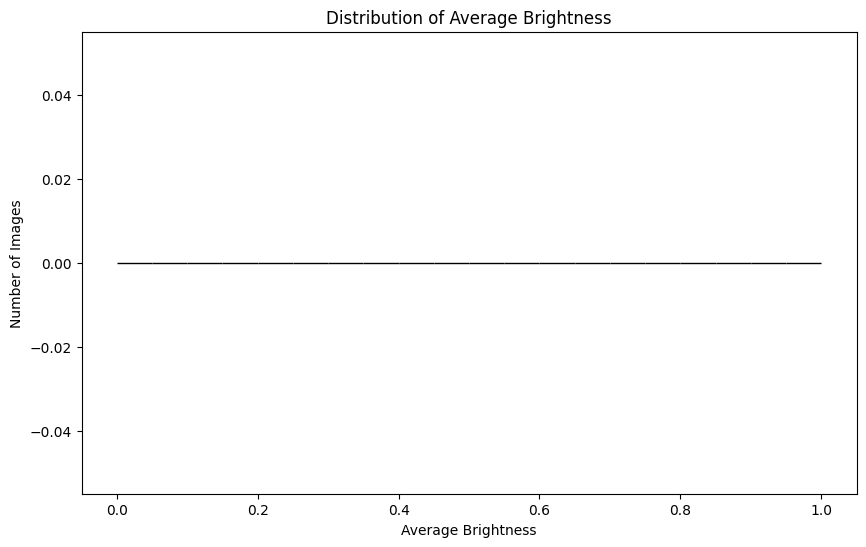

In [ ]:
# Average brightness distribution

avg_brightness_values = [f[0] for f in X_features]

plt.figure(figsize=(10, 6))
plt.hist(avg_brightness_values, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Average Brightness')
plt.ylabel('Number of Images')
plt.title('Distribution of Average Brightness')
plt.show()

In [ ]:
print(type(X_features))
print(len(X_features))

<class 'numpy.ndarray'>
0


In [ ]:
# Plot histogram of first image

hist_features_sample = X_features[0][1:]  # Skip average brightness
bins = np.linspace(0, 1, 11) # 10 bins -> 11 edges

plt.figure(figsize=(10, 6))
plt.plot(bins[:-1], hist_features_sample[:10], label='Red', color='r')
plt.plot(bins[:-1], hist_features_sample[10:20], label='Green', color='g')
plt.plot(bins[:-1], hist_features_sample[20:], label='Blue', color='b')
plt.xlabel('Pixel Intensity (Normalized)')
plt.ylabel('Density')
plt.title('Color Histogram of First Image')
plt.legend()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

CREATING THE MODEL